<a href="https://colab.research.google.com/github/swiz9/Flight-Delay-Prediction-System/blob/rnn-model/RNN_Flight_Delay_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# IMPORT LIBRARIES
import kagglehub
import pandas as pd
import zipfile
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import SimpleRNN, Dropout, Dense


**2. Data Loading**

In [2]:
#  DOWNLOAD DATASET FROM KAGGLE
path = kagglehub.dataset_download("patrickzel/flight-delay-and-cancellation-dataset-2019-2023")
print("Path to dataset files:", path)

#  UNZIP FILES
for file in os.listdir(path):
    if file.endswith(".zip"):
        zip_path = os.path.join(path, file)
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(path)
        print(" Files extracted to:", path)

#  LOAD CSV
csv_file = os.path.join(path, "flights_sample_3m.csv")
data = pd.read_csv(csv_file)

print(" Dataset loaded successfully!")
print(data.head())


100%|██████████| 140M/140M [00:00<00:00, 243MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/patrickzel/flight-delay-and-cancellation-dataset-2019-2023/versions/7
 Dataset loaded successfully!
      FL_DATE                AIRLINE                AIRLINE_DOT AIRLINE_CODE  \
0  2019-01-09  United Air Lines Inc.  United Air Lines Inc.: UA           UA   
1  2022-11-19   Delta Air Lines Inc.   Delta Air Lines Inc.: DL           DL   
2  2022-07-22  United Air Lines Inc.  United Air Lines Inc.: UA           UA   
3  2023-03-06   Delta Air Lines Inc.   Delta Air Lines Inc.: DL           DL   
4  2020-02-23       Spirit Air Lines       Spirit Air Lines: NK           NK   

   DOT_CODE  FL_NUMBER ORIGIN          ORIGIN_CITY DEST  \
0     19977       1562    FLL  Fort Lauderdale, FL  EWR   
1     19790       1149    MSP      Minneapolis, MN  SEA   
2     19977        459    DEN           Denver, CO  MSP   
3     19790       2295    MSP      Minneapolis, MN  SFO   
4     20416        407    MCO          Orlando, FL  DFW   

         

**3. Data Preprocessing & Exploration**

In [3]:
# Filter only delayed flights
data = data[data['ARR_DELAY'] > 0]

In [4]:
# Check the dataset shape
data.shape

(978147, 32)

In [5]:
# Check the data types of the dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 978147 entries, 3 to 2999997
Data columns (total 32 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   FL_DATE                  978147 non-null  object 
 1   AIRLINE                  978147 non-null  object 
 2   AIRLINE_DOT              978147 non-null  object 
 3   AIRLINE_CODE             978147 non-null  object 
 4   DOT_CODE                 978147 non-null  int64  
 5   FL_NUMBER                978147 non-null  int64  
 6   ORIGIN                   978147 non-null  object 
 7   ORIGIN_CITY              978147 non-null  object 
 8   DEST                     978147 non-null  object 
 9   DEST_CITY                978147 non-null  object 
 10  CRS_DEP_TIME             978147 non-null  int64  
 11  DEP_TIME                 978147 non-null  float64
 12  DEP_DELAY                978147 non-null  float64
 13  TAXI_OUT                 978147 non-null  float64
 14  WHEELS_O

**4. Exploratory Data Analysis (EDA)**

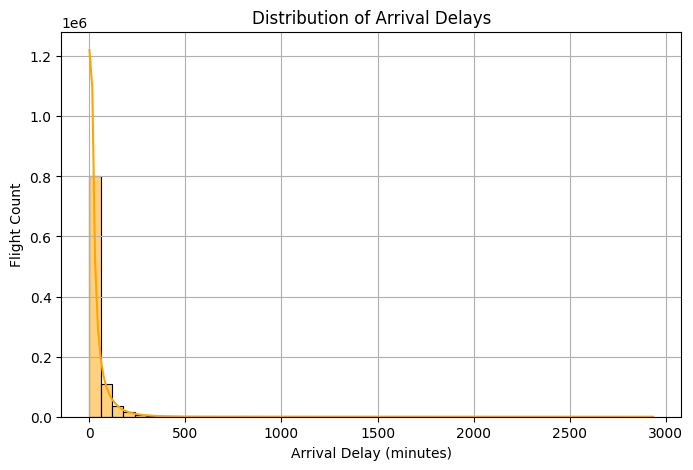

In [6]:
# --- Delay Distribution ---
plt.figure(figsize=(8, 5))
sns.histplot(data['ARR_DELAY'], bins=50, kde=True, color='orange')
plt.title('Distribution of Arrival Delays')
plt.xlabel('Arrival Delay (minutes)')
plt.ylabel('Flight Count')
plt.grid(True)
plt.show()


/tmp/ipython-input-1017356304.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=airline_delay.index, y=airline_delay.values, palette='coolwarm')


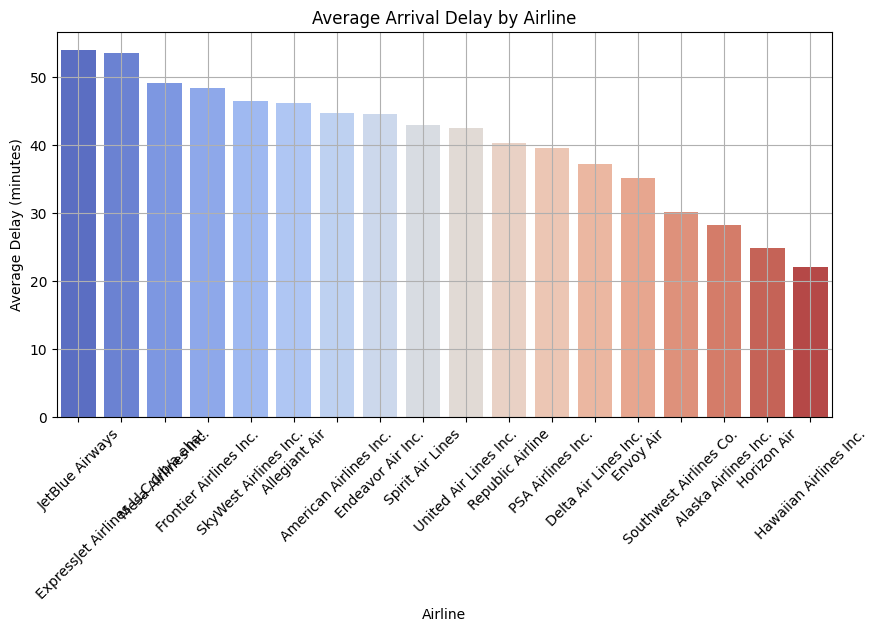

In [7]:
# --- Airline-wise Average Delay ---
plt.figure(figsize=(10, 5))
airline_delay = data.groupby('AIRLINE')['ARR_DELAY'].mean().sort_values(ascending=False)
sns.barplot(x=airline_delay.index, y=airline_delay.values, palette='coolwarm')
plt.title('Average Arrival Delay by Airline')
plt.xlabel('Airline')
plt.ylabel('Average Delay (minutes)')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

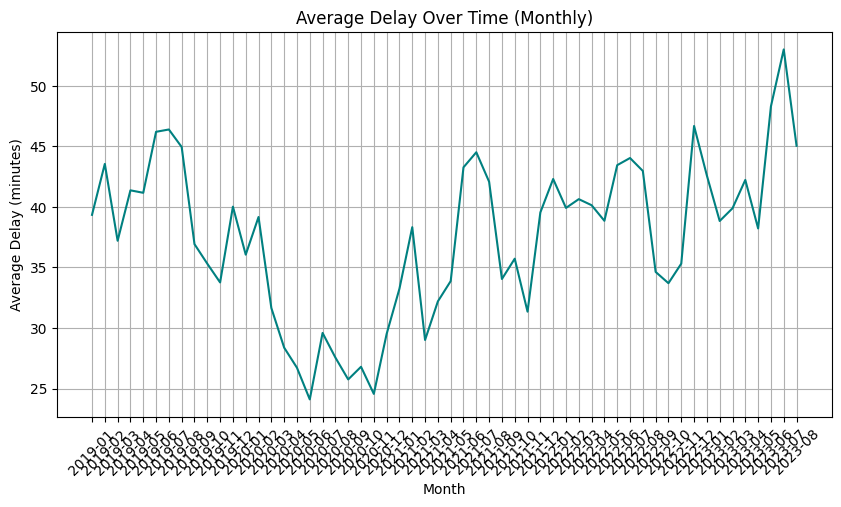

In [8]:
# --- Delay by Month ---
plt.figure(figsize=(10, 5))
month_delay = data.groupby(data['FL_DATE'].str[:7])['ARR_DELAY'].mean().reset_index()
sns.lineplot(x='FL_DATE', y='ARR_DELAY', data=month_delay, color='teal')
plt.title('Average Delay Over Time (Monthly)')
plt.xlabel('Month')
plt.ylabel('Average Delay (minutes)')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

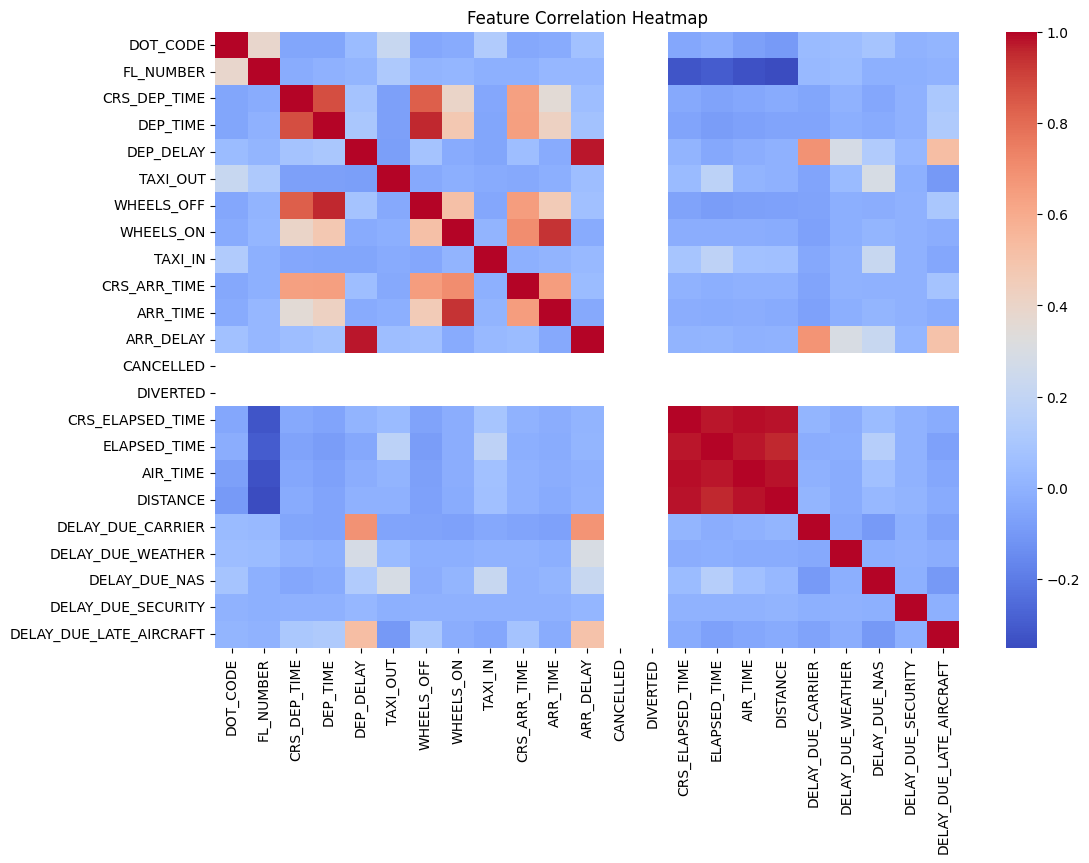

In [9]:
# --- Correlation Heatmap ---
plt.figure(figsize=(12, 8))
sns.heatmap(data.corr(numeric_only=True), cmap='coolwarm', annot=False)
plt.title('Feature Correlation Heatmap')
plt.show()